# Mixture of Experts - Benchmark

Comparison: Dense vs MoE Soft vs MoE Hard

## Configuration

In [22]:
# Experiment parameters
DATASET_NAME = "breast"      # iris, wine, covtype, breast
MAX_EXPERTS = 4                     # Number of experts for MoE
EPOCHS = 100
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
hidden_dim_dict = {
    'iris':32,
    'wine':64,
    "covtype":128,
    "breast":64,
}
HIDDEN_DIM = hidden_dim_dict.get(DATASET_NAME,128)
TEST_SIZE = 0.2
RANDOM_SEED = 42
HIDDEN_DIM_DENSE = MAX_EXPERTS * HIDDEN_DIM

print(f"Config: {DATASET_NAME} | Experts: {MAX_EXPERTS} | Epochs: {EPOCHS}")

Config: breast | Experts: 4 | Epochs: 100


## Imports

In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine, fetch_covtype, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from moe_model import DenseModel, MoE
from moe_hard_gate import MoETopK
from train import train_model, is_small_dataset

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Load Dataset

In [24]:
def load_dataset(name, test_size=0.2, seed=42):
    if name == "iris":
        X, y = load_iris(return_X_y=True)
    elif name == "wine":
        X, y = load_wine(return_X_y=True)
    elif name == "covtype":
        X, y = fetch_covtype(return_X_y=True)
        X = X[:100_000]
        y = y[:100_000]
        y = y - 1
    elif name == "breast":
        X,y = load_breast_cancer(return_X_y=True)
    else:
        raise ValueError(f"Unknown dataset: {name}")
    
    scaler = StandardScaler()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, shuffle=True
    )
    
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    X_train = torch.FloatTensor(X_train)
    y_train = torch.LongTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.LongTensor(y_test)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_dataset(DATASET_NAME, TEST_SIZE, RANDOM_SEED)
input_dim = X_train.shape[1]

output_dim = len(set(y_train.tolist()))
is_small = is_small_dataset(X_train.shape[0])

print(f"Train: {X_train.shape} | Test: {X_test.shape} | Classes: {output_dim}")
print(f"Type: {'small' if is_small else 'large'} dataset")

Train: torch.Size([455, 30]) | Test: torch.Size([114, 30]) | Classes: 2
Type: small dataset


## Training

In [25]:
results = {}

print("Training Dense...")
dense_model = DenseModel(input_dim, HIDDEN_DIM_DENSE, output_dim)
results['dense'] = train_model(
    dense_model, X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
    device=DEVICE, verbose=False
)
print(f"Dense - Accuracy: {results['dense']['final_accuracy']:.4f}")

print("Training MoE Soft...")
moe_soft = MoE(MAX_EXPERTS, input_dim, HIDDEN_DIM, output_dim)
results['moe_soft'] = train_model(
    moe_soft, X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
    device=DEVICE, verbose=False
)
print(f"MoE Soft - Accuracy: {results['moe_soft']['final_accuracy']:.4f}")

print("Training MoE Hard...")
moe_hard = MoETopK(MAX_EXPERTS, input_dim, HIDDEN_DIM, output_dim,k=1)
results['moe_hard'] = train_model(
    moe_hard, X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
    device=DEVICE, verbose=False
)
print(f"MoE Hard - Accuracy: {results['moe_hard']['final_accuracy']:.4f}")

Training Dense...
Dense - Accuracy: 0.9737
Training MoE Soft...
MoE Soft - Accuracy: 0.9737
Training MoE Hard...
MoE Hard - Accuracy: 0.9561


## Results Summary

In [26]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Dense', 'MoE Soft', 'MoE Hard'],
    'Accuracy': [results['dense']['final_accuracy'], 
                 results['moe_soft']['final_accuracy'],
                 results['moe_hard']['final_accuracy']],
    'Loss': [results['dense']['final_loss'],
             results['moe_soft']['final_loss'],
             results['moe_hard']['final_loss']]
})

print(summary.to_string(index=False))

   Model  Accuracy     Loss
   Dense  0.973684 0.064644
MoE Soft  0.973684 0.068335
MoE Hard  0.956140 0.112040


## Visualizations

Saved: metrics_breast_4experts_100epochs.png


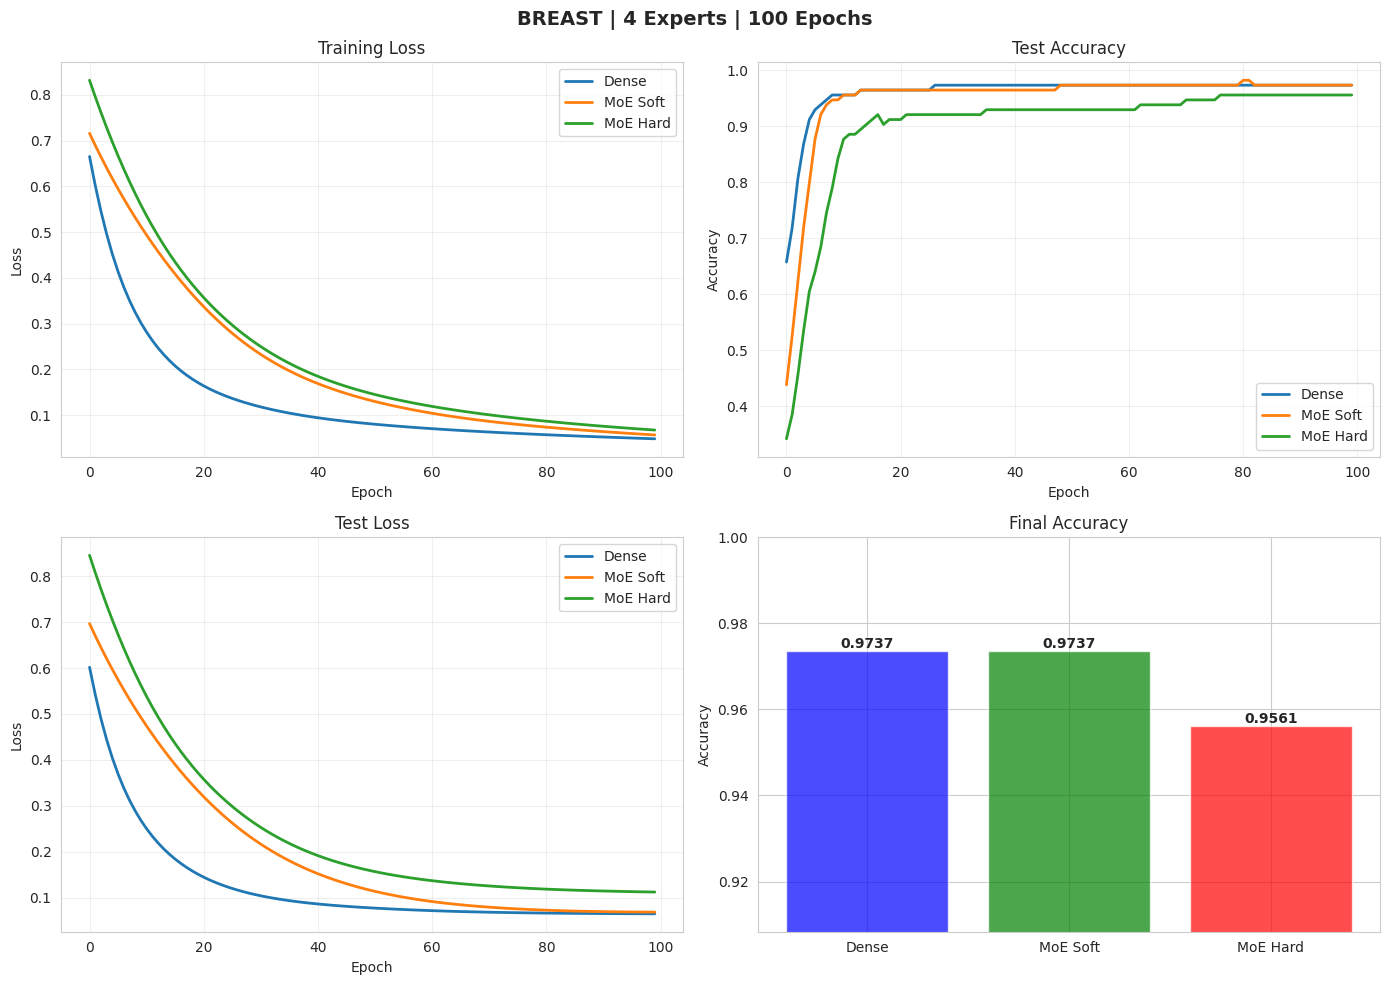

In [27]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
ax = axes[0, 0]
ax.plot(results['dense']['train_losses'], label='Dense', linewidth=2)
ax.plot(results['moe_soft']['train_losses'], label='MoE Soft', linewidth=2)
ax.plot(results['moe_hard']['train_losses'], label='MoE Hard', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Test Accuracy
ax = axes[0, 1]
ax.plot(results['dense']['test_accuracies'], label='Dense', linewidth=2)
ax.plot(results['moe_soft']['test_accuracies'], label='MoE Soft', linewidth=2)
ax.plot(results['moe_hard']['test_accuracies'], label='MoE Hard', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Test Loss
ax = axes[1, 0]
ax.plot(results['dense']['test_losses'], label='Dense', linewidth=2)
ax.plot(results['moe_soft']['test_losses'], label='MoE Soft', linewidth=2)
ax.plot(results['moe_hard']['test_losses'], label='MoE Hard', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Final Accuracy Comparison
ax = axes[1, 1]
models = ['Dense', 'MoE Soft', 'MoE Hard']
accs = [results['dense']['final_accuracy'], 
        results['moe_soft']['final_accuracy'],
        results['moe_hard']['final_accuracy']]
bars = ax.bar(models, accs, color=['blue', 'green', 'red'], alpha=0.7)
ax.set_ylabel('Accuracy')
ax.set_title('Final Accuracy')
ax.set_ylim([min(accs) * 0.95, 1.0])
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

fig.suptitle(f'{DATASET_NAME.upper()} | {MAX_EXPERTS} Experts | {EPOCHS} Epochs', fontsize=14, fontweight='bold')
plt.tight_layout()
filename = f'metrics_{DATASET_NAME}_{MAX_EXPERTS}experts_{EPOCHS}epochs.png'
plt.savefig(f'assets/{filename}', dpi=150, bbox_inches='tight')
print(f"Saved: {filename}")
plt.show()

## Expert Distribution

Saved: experts_breast_4experts.png


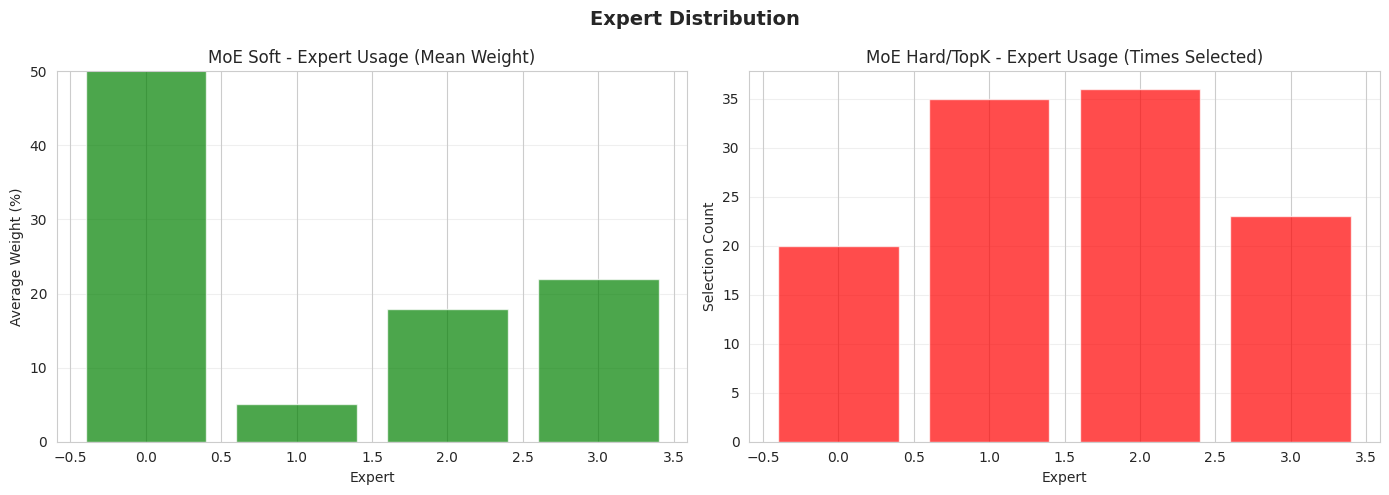

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# MoE Soft expert usage - poids moyens
if results['moe_soft']['expert_counts'] is not None:
    ax = axes[0]
    counts = results['moe_soft']['expert_counts']
    ax.bar(range(len(counts)), counts * 100, color='green', alpha=0.7)
    ax.set_xlabel('Expert')
    ax.set_ylabel('Average Weight (%)')
    ax.set_title('MoE Soft - Expert Usage (Mean Weight)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100/len(counts) * 2])  # Scale for readability

# MoE Hard expert usage - count
if results['moe_hard']['expert_counts'] is not None:
    ax = axes[1]
    counts = results['moe_hard']['expert_counts']
    ax.bar(range(len(counts)), counts, color='red', alpha=0.7)
    ax.set_xlabel('Expert')
    ax.set_ylabel('Selection Count')
    ax.set_title('MoE Hard/TopK - Expert Usage (Times Selected)')
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Expert Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
filename = f'experts_{DATASET_NAME}_{MAX_EXPERTS}experts.png'
plt.savefig(f'assets/{filename}', dpi=150, bbox_inches='tight')
print(f"Saved: {filename}")
plt.show()

## Scaling Analysis - Experts Impact

In [29]:
expert_range = [2, 4, 6, 8, 10]
scaling_results = {
    'dense': {'accs': [], 'losses': []},
    'moe_soft': {'accs': [], 'losses': []},
    'moe_hard': {'accs': [], 'losses': []}
}

for num_exp in expert_range:
    print(f"\nTraining with {num_exp} experts...")
    
    # Dense (scale hidden dim with num_exp for fair comparison)
    hidden_dense = num_exp * HIDDEN_DIM
    dense_m = DenseModel(input_dim, hidden_dense, output_dim)
    dense_r = train_model(dense_m, X_train, y_train, X_test, y_test,
                          epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                          device=DEVICE, verbose=False)
    
    scaling_results['dense']['accs'].append(dense_r['final_accuracy'])
    scaling_results['dense']['losses'].append(dense_r['final_loss'])
    
    # MoE Soft
    moe_s = MoE(num_exp, input_dim, HIDDEN_DIM, output_dim)
    moe_s_r = train_model(moe_s, X_train, y_train, X_test, y_test,
                         epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                         device=DEVICE, verbose=False)
    scaling_results['moe_soft']['accs'].append(moe_s_r['final_accuracy'])
    scaling_results['moe_soft']['losses'].append(moe_s_r['final_loss'])
    
    # MoE Hard
    moe_h = MoETopK(num_exp, input_dim, HIDDEN_DIM, output_dim, k=1)
    moe_h_r = train_model(moe_h, X_train, y_train, X_test, y_test,
                         epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                         device=DEVICE, verbose=False)
    scaling_results['moe_hard']['accs'].append(moe_h_r['final_accuracy'])
    scaling_results['moe_hard']['losses'].append(moe_h_r['final_loss'])
    
    print(f"  Dense: {dense_r['final_accuracy']:.4f} | MoE Soft: {moe_s_r['final_accuracy']:.4f} | MoE Hard: {moe_h_r['final_accuracy']:.4f}")


Training with 2 experts...
  Dense: 0.9825 | MoE Soft: 0.9737 | MoE Hard: 0.9737

Training with 4 experts...
  Dense: 0.9649 | MoE Soft: 0.9737 | MoE Hard: 0.9737

Training with 6 experts...
  Dense: 0.9825 | MoE Soft: 0.9825 | MoE Hard: 0.9649

Training with 8 experts...
  Dense: 0.9737 | MoE Soft: 0.9737 | MoE Hard: 0.9649

Training with 10 experts...
  Dense: 0.9649 | MoE Soft: 0.9912 | MoE Hard: 0.9825


## Scaling Analysis - Visualization

Saved: scaling_breast.png


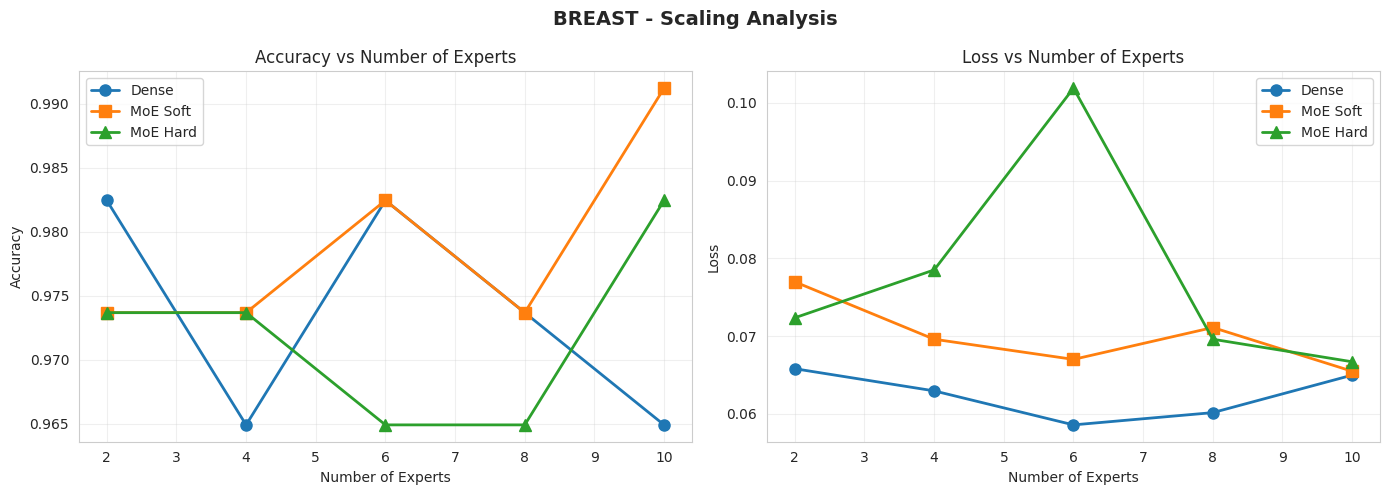

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Experts
ax = axes[0]
ax.plot(expert_range, scaling_results['dense']['accs'], 'o-', label='Dense', linewidth=2, markersize=8)
ax.plot(expert_range, scaling_results['moe_soft']['accs'], 's-', label='MoE Soft', linewidth=2, markersize=8)
ax.plot(expert_range, scaling_results['moe_hard']['accs'], '^-', label='MoE Hard', linewidth=2, markersize=8)
ax.set_xlabel('Number of Experts')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Number of Experts')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss vs Experts
ax = axes[1]
ax.plot(expert_range, scaling_results['dense']['losses'], 'o-', label='Dense', linewidth=2, markersize=8)
ax.plot(expert_range, scaling_results['moe_soft']['losses'], 's-', label='MoE Soft', linewidth=2, markersize=8)
ax.plot(expert_range, scaling_results['moe_hard']['losses'], '^-', label='MoE Hard', linewidth=2, markersize=8)
ax.set_xlabel('Number of Experts')
ax.set_ylabel('Loss')
ax.set_title('Loss vs Number of Experts')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(f'{DATASET_NAME.upper()} - Scaling Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
filename = f'scaling_{DATASET_NAME}.png'
plt.savefig(f'assets/{filename}', dpi=150, bbox_inches='tight')
print(f"Saved: {filename}")
plt.show()